In [1]:
# importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # task 4
from scipy.stats import zscore #task 4
from scipy import stats #task 4
import matplotlib.pyplot as plt #tash 5
from scipy.stats import ttest_ind  #task 6

In [2]:
GS = pd.read_csv(r"C:\Users\TRIDEV PAL\Documents\PYTHON HAND ON\goldman_sachs.csv")

In [3]:
GS.head(5)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,63709.51436,175247.5395,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,82926.69313,172192.6604,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,26407.07559,168187.0333,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,46049.09381,166962.4001,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,17842.12843,161904.9277,0.289304,468,234


#                                               TASK 1

### Remove/treat any special characters or non-numeric entries from financial fields.

In [4]:
GS['TransactionAmount'] = (
    GS['TransactionAmount']
    .astype(str)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .astype(float)
)

GS['AccountBalance'] = (
    GS['AccountBalance']
    .astype(str)
    .str.replace(r'[^0-9\.-]', '', regex=True)
    .astype(float)
)


In [5]:
GS['AccountBalance'].head(10)

0    175247.5395
1    172192.6604
2    168187.0333
3    166962.4001
4    161904.9277
5    158520.0411
6    156472.2656
7    152879.4845
8    150498.1361
9    150199.0786
Name: AccountBalance, dtype: float64

In [6]:
GS.dtypes

TransactionID          int64
CustomerID            object
AccountID             object
AccountType           object
TransactionType       object
Product               object
Firm                  object
Region                object
Manager               object
TransactionDate       object
TransactionAmount    float64
AccountBalance       float64
RiskScore            float64
CreditRating           int64
TenureMonths           int64
dtype: object

### ● Convert currency amounts into numerical format.

In [7]:
GS['TransactionAmount'] = (
    GS['TransactionAmount']
    .astype(str)
    .str.replace(r'[^0-9\.-]', '', regex=True)   # remove ₹ $
    .astype(float)
)

In [8]:
GS['TransactionAmount'].head(10)

0     63709.51436
1     82926.69313
2     26407.07559
3     46049.09381
4     17842.12843
5     47036.07213
6     35454.03812
7     23629.27606
8     85181.44076
9    128816.23600
Name: TransactionAmount, dtype: float64

### ● Validate and format date columns.

In [9]:
GS['TransactionDate'].head(7)

0    21-10-2023
1    20-06-2023
2    02-01-2023
3    25-07-2023
4    25-07-2023
5    01-01-2024
6    08-01-2024
Name: TransactionDate, dtype: object

In [10]:
GS.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,21-10-2023,63709.51436,175247.5395,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,20-06-2023,82926.69313,172192.6604,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,02-01-2023,26407.07559,168187.0333,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,25-07-2023,46049.09381,166962.4001,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,25-07-2023,17842.12843,161904.9277,0.289304,468,234


In [11]:
GS["TransactionDate"] = pd.to_datetime(GS["TransactionDate"], format="%d-%m-%Y")

In [12]:
print(GS['TransactionDate'].dtype)

datetime64[ns]


In [13]:
GS.dtypes

TransactionID                 int64
CustomerID                   object
AccountID                    object
AccountType                  object
TransactionType              object
Product                      object
Firm                         object
Region                       object
Manager                      object
TransactionDate      datetime64[ns]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object

### ● Ensure account types and transaction categories are standardized.

In [14]:
GS.head(10)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,63709.51436,175247.5395,0.729101,319,200
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,82926.69313,172192.6604,0.472424,692,47
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,26407.07559,168187.0333,0.648784,543,109
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,46049.09381,166962.4001,0.734832,430,103
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,17842.12843,161904.9277,0.289304,468,234
5,96,CUST4684,ACC45101,Savings,Deposit,Personal Loan,Firm D,South,Manager 1,2024-01-01,47036.07213,158520.0411,0.399780,437,65
6,57,CUST8416,ACC49422,Loan,Deposit,Credit Card,Firm A,West,Manager 4,2024-01-08,35454.03812,156472.2656,0.527219,632,63
7,27,CUST9731,ACC12182,Loan,Payment,Savings Account,Firm A,North,Manager 2,2023-10-16,23629.27606,152879.4845,0.840356,487,186
8,25,CUST8155,ACC11188,Credit,Withdrawal,Personal Loan,Firm E,South,Manager 4,2023-10-24,85181.44076,150498.1361,0.314228,517,207
9,138,CUST2067,ACC28292,Credit,Deposit,Savings Account,Firm B,West,Manager 4,2024-01-08,128816.23600,150199.0786,0.456503,324,68


In [15]:
# GS['AccountType'] = GS['AccountType'].str.lower().str.strip()
# GS['TransactionType'] = GS['TransactionType'].str.lower().str.strip()

#                                                      Task 2

### Calculate monthly and yearly summaries of total credits, debits, and net transaction volume.

In [16]:
GS['Year'] = GS['TransactionDate'].dt.year
GS['Month'] = GS['TransactionDate'].dt.to_period('M')

In [17]:
GS.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,63709.51436,175247.5395,0.729101,319,200,2023,2023-10
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,82926.69313,172192.6604,0.472424,692,47,2023,2023-06
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,26407.07559,168187.0333,0.648784,543,109,2023,2023-01
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,46049.09381,166962.4001,0.734832,430,103,2023,2023-07
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,17842.12843,161904.9277,0.289304,468,234,2023,2023-07


In [18]:
monthly_summary = GS.pivot_table(
    index='Month',
    columns='AccountType', 
    values='TransactionAmount', 
    aggfunc='sum',
    fill_value=0
)

monthly_summary['Net_Transaction'] = (
    monthly_summary.get('credit', 0) - monthly_summary.get('Loan', 0)
)

monthly_summary

AccountType,Credit,Current,Loan,Savings,Net_Transaction
Month,,,,,
2023-01,729802.816430,5.823329e+05,9.545325e+05,718000.922809,-9.545325e+05
2023-02,370415.037735,2.517934e+05,4.822689e+05,729623.019346,-4.822689e+05
2023-03,724955.292830,4.285532e+05,5.501307e+05,409363.105504,-5.501307e+05
2023-04,276066.698420,2.269032e+05,5.195343e+05,781989.955886,-5.195343e+05
2023-05,625550.564800,3.787807e+05,1.004957e+06,452150.274080,-1.004957e+06
2023-06,528357.756993,1.413483e+05,2.827354e+05,293954.257040,-2.827354e+05
2023-07,472241.530970,6.578236e+05,4.827842e+05,309585.531141,-4.827842e+05
2023-08,425523.516195,5.443224e+05,9.035241e+05,623122.278690,-9.035241e+05
2023-09,615109.758063,1.028423e+06,6.957709e+05,433301.328710,-6.957709e+05


In [19]:
yearly_summary = GS.pivot_table(
    index='Year',
    columns='AccountType',
    values='TransactionAmount',
    aggfunc='sum',
    fill_value=0
)

yearly_summary['Net_Transaction'] = (
    yearly_summary.get('credit', 0) - yearly_summary.get('Loan', 0)
)

yearly_summary

AccountType,Credit,Current,Loan,Savings,Net_Transaction
Year,,,,,
2023,6.853931e+06,5.633183e+06,8.337574e+06,6.602956e+06,-8.337574e+06
2024,3.681608e+06,3.124815e+06,3.465631e+06,3.560839e+06,-3.465631e+06


### ● Plot trends in total credits vs. debits over time.

In [20]:
import matplotlib.pyplot as plt

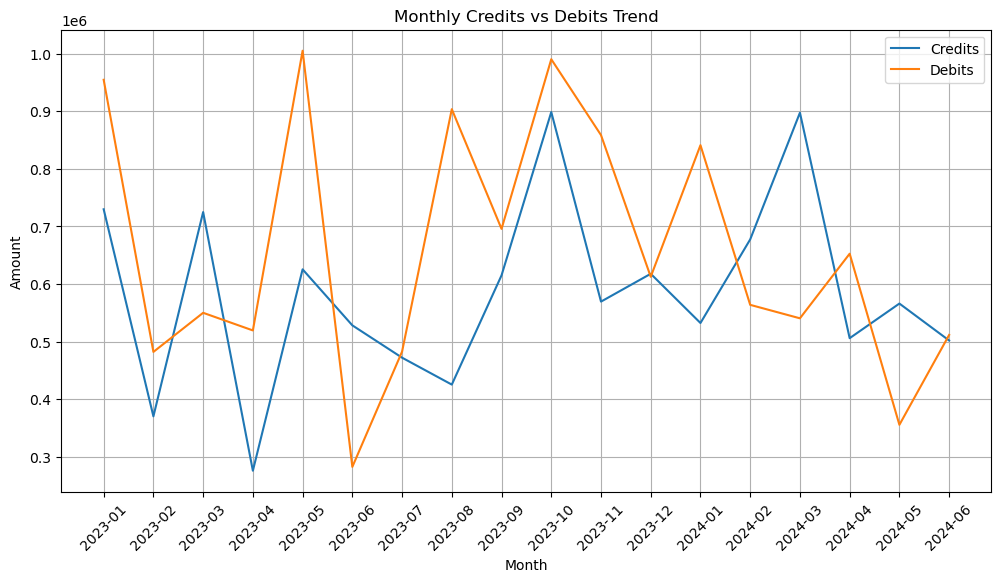

In [21]:
GS['Month'] = GS['TransactionDate'].dt.to_period('M')

monthly_trend = GS.pivot_table(
    index='Month',
    columns='AccountType',
    values='TransactionAmount',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(12,6))
plt.plot(monthly_trend.index.astype(str), monthly_trend['Credit'], label='Credits')
plt.plot(monthly_trend.index.astype(str), monthly_trend['Loan'], label='Debits')
plt.title("Monthly Credits vs Debits Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [22]:
GS.head(7)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,Year,Month
0,33,CUST6549,ACC12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,63709.51436,175247.5395,0.729101,319,200,2023,2023-10
1,177,CUST2942,ACC52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,82926.69313,172192.6604,0.472424,692,47,2023,2023-06
2,178,CUST6776,ACC45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,26407.07559,168187.0333,0.648784,543,109,2023,2023-01
3,173,CUST2539,ACC88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,46049.09381,166962.4001,0.734832,430,103,2023,2023-07
4,67,CUST2626,ACC21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,17842.12843,161904.9277,0.289304,468,234,2023,2023-07
5,96,CUST4684,ACC45101,Savings,Deposit,Personal Loan,Firm D,South,Manager 1,2024-01-01,47036.07213,158520.0411,0.399780,437,65,2024,2024-01
6,57,CUST8416,ACC49422,Loan,Deposit,Credit Card,Firm A,West,Manager 4,2024-01-08,35454.03812,156472.2656,0.527219,632,63,2024,2024-01


### ● Identify top and bottom performing accounts based on net inflow.

In [23]:
yearly_summary = GS.pivot_table(
    columns='AccountType',
    values='TransactionAmount',
    aggfunc='sum',
    fill_value=0
)

yearly_summary['Net_Transaction'] = (
    yearly_summary.get('credit', 0) - yearly_summary.get('Loan', 0)
)

yearly_summary

AccountType,Credit,Current,Loan,Savings,Net_Transaction
TransactionAmount,1.053554e+07,8.757998e+06,1.180320e+07,1.016379e+07,-1.180320e+07


In [24]:
# Convert TransactionType into Debit/Credit
def classify_dc(ttype):
    ttype = ttype.lower()
    
    # Money IN (Credit)
    credit_keywords = ['deposit']
    
    # Money OUT (Debit)
    debit_keywords  = ['withdrawal', 'payment', 'transfer',]
    
    if any(word in ttype for word in credit_keywords):
        return "Credit"
    elif any(word in ttype for word in debit_keywords):
        return "Debit"
    else:
        return "Unknown"

GS["DC"] = GS["TransactionType"].apply(classify_dc)

In [25]:
GS["TransactionType"].unique()

array(['Withdrawal', 'Deposit', 'Payment', 'Transfer'], dtype=object)

In [26]:
GS["SignedAmount"] = GS.apply(
    lambda x: x["TransactionAmount"] if x["DC"] == "Credit" else -x["TransactionAmount"],
    axis=1
)

In [27]:
net_inflow = GS.groupby("AccountID")["SignedAmount"].sum().reset_index()
net_inflow.rename(columns={"SignedAmount": "NetInflow"}, inplace=True)

In [28]:
# Top 5 with highest inflow
top_accounts = net_inflow.sort_values(by="NetInflow", ascending=False).head(5)

# Bottom 5 with lowest (or negative) inflow
bottom_accounts = net_inflow.sort_values(by="NetInflow").head(5)

In [29]:
net_inflow

,AccountID,NetInflow
0,ACC10117,52654.05067
1,ACC10996,-221217.15743
2,ACC11062,-99958.62100
3,ACC11188,-196989.74088
4,ACC11285,-73697.62185
...,...,...
189,ACC97225,14127.66931
190,ACC97411,-88698.39350
191,ACC99117,26451.20132
192,ACC99409,-201138.27294


In [30]:
display(top_accounts)
display(bottom_accounts)

,AccountID,NetInflow
92,ACC48501,207517.171810
100,ACC50817,96789.234080
76,ACC40952,84626.394860
168,ACC87006,70999.889021
86,ACC45951,69704.940940


,AccountID,NetInflow
48,ACC29356,-498295.558960
107,ACC53466,-446411.169410
14,ACC16664,-411852.306754
171,ACC88252,-384345.744960
159,ACC82298,-356063.288070


### ● Identify and flag accounts as dormant or inactive if there is a gap of two months or more between consecutive transactions.

In [31]:
GS = GS.sort_values(["AccountID", "TransactionDate"])

In [32]:
GS["PrevDate"] = GS.groupby("AccountID")["TransactionDate"].shift(1)

GS["Gap_Days"] = (GS["TransactionDate"] - GS["PrevDate"]).dt.days

In [33]:
GS["DormantFlag"] = GS["Gap_Days"].apply(lambda x: "Dormant" if x >= 60 else "Active")

In [34]:
dormant_accounts = GS[GS["DormantFlag"] == "Dormant"]["AccountID"].unique()
dormant_accounts

array(['ACC10117', 'ACC10996', 'ACC11062', 'ACC11188', 'ACC11837',
       'ACC12182', 'ACC12334', 'ACC13357', 'ACC15228', 'ACC15359',
       'ACC15671', 'ACC15925', 'ACC16241', 'ACC16664', 'ACC18057',
       'ACC18140', 'ACC18177', 'ACC19156', 'ACC20297', 'ACC21719',
       'ACC21878', 'ACC22036', 'ACC22255', 'ACC22799', 'ACC23736',
       'ACC23985', 'ACC24070', 'ACC24880', 'ACC24981', 'ACC25132',
       'ACC25811', 'ACC26026', 'ACC26940', 'ACC26973', 'ACC28154',
       'ACC28292', 'ACC28295', 'ACC28305', 'ACC29007', 'ACC29231',
       'ACC29356', 'ACC29396', 'ACC29477', 'ACC30146', 'ACC30787',
       'ACC31539', 'ACC31902', 'ACC32212', 'ACC32627', 'ACC32890',
       'ACC33287', 'ACC34119', 'ACC34431', 'ACC34821', 'ACC35419',
       'ACC36079', 'ACC37688', 'ACC38559', 'ACC39161', 'ACC39482',
       'ACC39500', 'ACC39529', 'ACC39544', 'ACC40939', 'ACC40952',
       'ACC41829', 'ACC42467', 'ACC42710', 'ACC42903', 'ACC45101',
       'ACC45521', 'ACC45907', 'ACC45951', 'ACC46655', 'ACC470

In [35]:
GS[GS["DormantFlag"] == "Dormant"]

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag
87,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,0.736631,573,109,2023,2023-06,Credit,45748.34156,2023-02-21,117.0,Dormant
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,0.371513,697,218,2024,2024-03,Credit,-14452.52809,2023-06-18,270.0,Dormant
294,93,CUST6776,ACC10996,Savings,Payment,Savings Account,Firm C,North,Manager 4,2023-10-19,...,0.289781,510,103,2023,2023-10,Debit,-75087.04895,2023-05-08,164.0,Dormant
574,22,CUST6565,ACC10996,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2024-01-29,...,0.593555,550,201,2024,2024-01,Debit,-101207.86740,2023-10-21,100.0,Dormant
551,62,CUST9666,ACC11062,Savings,Payment,Credit Card,Firm C,South,Manager 3,2024-02-08,...,0.245529,705,84,2024,2024-02,Debit,-25651.05823,2023-11-08,92.0,Dormant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,55,CUST5253,ACC99409,Current,Transfer,Mutual Fund,Firm D,East,Manager 1,2023-09-30,...,0.587029,764,224,2023,2023-09,Debit,-61255.52247,2023-05-04,149.0,Dormant
542,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,0.329888,565,167,2024,2024-03,Debit,-103334.77070,2023-10-04,170.0,Dormant
504,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,0.432719,541,128,2023,2023-08,Debit,-105887.35330,2023-04-14,112.0,Dormant
706,25,CUST4258,ACC99549,Loan,Transfer,Mutual Fund,Firm E,West,Manager 2,2023-10-26,...,0.552694,767,47,2023,2023-10,Debit,-73103.55049,2023-08-04,83.0,Dormant


In [36]:
GS.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,RiskScore,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag
468,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,0.354694,354,60,2023,2023-01,Debit,-47132.14075,NaT,NaN,Active
25,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,0.206170,611,85,2023,2023-02,Credit,68490.37795,2023-01-30,22.0,Active
87,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,0.736631,573,109,2023,2023-06,Credit,45748.34156,2023-02-21,117.0,Dormant
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,0.371513,697,218,2024,2024-03,Credit,-14452.52809,2023-06-18,270.0,Dormant
384,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,0.748719,557,233,2023,2023-05,Debit,-35471.89391,NaT,NaN,Active


#                                                          Task 3

### ● Group accounts by activity levels: High, Medium, Low based on transaction frequency on your analysis and rubrics. Do not forget to mention the rubric in the headings.

In [37]:
GS["YearMonth"] = GS["TransactionDate"].dt.to_period("M")

In [38]:
monthly_txn = GS.groupby(["AccountID", "YearMonth"]).size().reset_index(name="TxnCount")

In [39]:
avg_txn = monthly_txn.groupby("AccountID")["TxnCount"].mean().reset_index()
avg_txn.rename(columns={"TxnCount": "AvgMonthlyTxn"}, inplace=True)

In [40]:
def classify_activity(x):
    if x >= 2:
        return "High Activity"
    elif x >= 1:
        return "Medium Activity"
    else:
        return "Low Activity"

avg_txn["ActivityLevel"] = avg_txn["AvgMonthlyTxn"].apply(classify_activity)

In [41]:
avg_txn.head()

,AccountID,AvgMonthlyTxn,ActivityLevel
0,ACC10117,1.00,Medium Activity
1,ACC10996,1.25,Medium Activity
2,ACC11062,1.00,Medium Activity
3,ACC11188,1.00,Medium Activity
4,ACC11285,1.00,Medium Activity


In [42]:
avg_txn.shape

(194, 3)

In [43]:
GS.shape

(800, 23)

In [44]:
high_activity = avg_txn[avg_txn["ActivityLevel"] == "High Activity"]
high_activity

,AccountID,AvgMonthlyTxn,ActivityLevel
167,ACC86784,2.0,High Activity
188,ACC96868,2.0,High Activity


In [45]:
high_activity.shape

(2, 3)

In [46]:
low_activity = avg_txn[avg_txn["ActivityLevel"] == "Low Activity"]

In [47]:
low_activity.shape

(0, 3)

### ● Segment customers by average balance and transaction volume.

In [48]:
avg_balance = GS.groupby("CustomerID")["AccountBalance"].mean().reset_index()
avg_balance.rename(columns={"AccountBalance": "AvgBalance"}, inplace=True)

In [49]:
txn_volume = GS.groupby("CustomerID").size().reset_index(name="TxnCount")

In [50]:
customer_seg = avg_balance.merge(txn_volume, on="CustomerID")

In [51]:
def balance_segment(x):
    if x >= 100000:
        return "High Balance"
    elif x >= 40000:
        return "Medium Balance"
    else:
        return "Low Balance"

In [52]:
def volume_segment(x):
    if x >= 9:
        return "High Volume"
    elif x >= 5:
        return "Medium Volume"
    else:
        return "Low Volume"

In [53]:
customer_seg["BalanceSegment"] = customer_seg["AvgBalance"].apply(balance_segment)
customer_seg["VolumeSegment"] = customer_seg["TxnCount"].apply(volume_segment)

In [54]:
customer_seg

,CustomerID,AvgBalance,TxnCount,BalanceSegment,VolumeSegment
0,CUST1042,52279.762062,8,Medium Balance,Medium Volume
1,CUST1114,68883.011356,8,Medium Balance,Medium Volume
2,CUST1121,41058.834537,4,Medium Balance,Low Volume
3,CUST1189,93897.330747,3,Medium Balance,Low Volume
4,CUST1223,76982.353010,2,Medium Balance,Low Volume
...,...,...,...,...,...
183,CUST9683,69088.592343,7,Medium Balance,Medium Volume
184,CUST9731,96230.457993,6,Medium Balance,Medium Volume
185,CUST9754,44390.423177,8,Medium Balance,Medium Volume
186,CUST9843,82953.858990,4,Medium Balance,Low Volume


In [55]:
customer_seg[customer_seg["BalanceSegment"] == "High Balance"]

,CustomerID,AvgBalance,TxnCount,BalanceSegment,VolumeSegment
9,CUST1498,109090.804300,2,High Balance,Low Volume
40,CUST2626,103476.046010,2,High Balance,Low Volume
48,CUST2942,107736.325953,4,High Balance,Low Volume
59,CUST3306,108635.894737,4,High Balance,Low Volume
84,CUST4684,102413.953432,4,High Balance,Low Volume
90,CUST4884,109660.123900,1,High Balance,Low Volume
108,CUST5894,119359.535150,2,High Balance,Low Volume
144,CUST7651,100075.898360,4,High Balance,Low Volume
145,CUST7730,113344.849347,4,High Balance,Low Volume


In [56]:
customer_seg[customer_seg["VolumeSegment"] == "High Volume"]

,CustomerID,AvgBalance,TxnCount,BalanceSegment,VolumeSegment
51,CUST3015,70705.770270,11,Medium Balance,High Volume
76,CUST4373,81409.340291,9,Medium Balance,High Volume
93,CUST5174,82682.938127,10,Medium Balance,High Volume
163,CUST8529,90171.259711,9,Medium Balance,High Volume
166,CUST8772,70597.564776,9,Medium Balance,High Volume


### Create profiles for:
○ High-net inflow accounts
○ High-frequency low-balance accounts
○ Accounts with negative or near-zero balances

In [57]:
avg_bal = GS.groupby("AccountID")["AccountBalance"].mean().reset_index()
avg_bal.rename(columns={"AccountBalance": "AvgBalance"}, inplace=True)

In [58]:
avg_bal = GS.groupby("AccountID")["AccountBalance"].sum()
avg_bal

AccountID
ACC10117    335724.161910
ACC10996    404306.305350
ACC11062    109431.412990
ACC11188    401239.220520
ACC11285    212557.873590
                ...      
ACC97225    219397.982830
ACC97411    101150.065459
ACC99117    158869.362390
ACC99409    230566.856650
ACC99549    246366.986620
Name: AccountBalance, Length: 194, dtype: float64

In [59]:
txn_count = GS.groupby("AccountID").size().reset_index(name="TxnCount")
txn_count

,AccountID,TxnCount
0,ACC10117,4
1,ACC10996,5
2,ACC11062,2
3,ACC11188,5
4,ACC11285,3
...,...,...
189,ACC97225,3
190,ACC97411,2
191,ACC99117,3
192,ACC99409,4


In [60]:
profile_df = net_inflow.merge(avg_bal, on="AccountID").merge(txn_count, on="AccountID")

In [61]:
high_net_inflow = profile_df[profile_df["NetInflow"] > 50000]
high_net_inflow

,AccountID,NetInflow,AccountBalance,TxnCount
0,ACC10117,52654.050670,335724.16191,4
32,ACC24508,61445.424570,94539.20942,1
34,ACC24981,53809.828237,410033.02104,4
51,ACC29646,55681.908760,60258.19912,1
76,ACC40952,84626.394860,81661.54008,2
86,ACC45951,69704.940940,235579.39578,3
92,ACC48501,207517.171810,392434.29700,5
100,ACC50817,96789.234080,364133.31040,5
168,ACC87006,70999.889021,660620.82599,8


In [62]:
high_net_inflow .to_csv("hg.csv",index=False)

In [63]:
high_freq_low_bal = profile_df[
    (profile_df["TxnCount"] >=9) &
    (profile_df["AccountBalance"] >= 40000)
]

In [64]:
high_freq_low_bal

,AccountID,NetInflow,AccountBalance,TxnCount
13,ACC16241,-315148.729270,820412.147590,10
42,ACC28292,-231822.913620,656215.421880,10
48,ACC29356,-498295.558960,547517.069012,9
88,ACC46655,-345037.006933,886470.712199,14
107,ACC53466,-446411.169410,656969.233214,9
153,ACC78178,-242448.871825,564681.597730,9


In [65]:
zero_or_negative_bal = profile_df[profile_df["AccountBalance"] <= 1000]
zero_or_negative_bal

,AccountID,NetInflow,AccountBalance,TxnCount


#                                                               Task 4

### ● Track accounts with frequent large withdrawals or overdrafts.

In [66]:
withdrawals = GS[GS["DC"] == "Debit"]

In [67]:
large_withdrawals = withdrawals[withdrawals["TransactionAmount"] >= 50000]

In [68]:
large_withdrawals

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth
294,93,CUST6776,ACC10996,Savings,Payment,Savings Account,Firm C,North,Manager 4,2023-10-19,...,510,103,2023,2023-10,Debit,-75087.04895,2023-05-08,164.0,Dormant,2023-10
396,88,CUST6776,ACC10996,Credit,Transfer,Home Loan,Firm C,North,Manager 2,2023-10-21,...,333,207,2023,2023-10,Debit,-56709.75712,2023-10-19,2.0,Active,2023-10
574,22,CUST6565,ACC10996,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2024-01-29,...,550,201,2024,2024-01,Debit,-101207.86740,2023-10-21,100.0,Dormant,2024-01
557,115,CUST8091,ACC11062,Credit,Payment,Mutual Fund,Firm B,Central,Manager 1,2023-11-08,...,384,71,2023,2023-11,Debit,-74307.56277,NaT,NaN,Active,2023-11
328,63,CUST1840,ACC11188,Current,Withdrawal,Mutual Fund,Firm B,South,Manager 3,2023-06-18,...,406,216,2023,2023-06,Debit,-62540.67289,2023-05-04,45.0,Active,2023-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,55,CUST5253,ACC99409,Current,Transfer,Mutual Fund,Firm D,East,Manager 1,2023-09-30,...,764,224,2023,2023-09,Debit,-61255.52247,2023-05-04,149.0,Dormant,2023-09
542,45,CUST7887,ACC99409,Current,Withdrawal,Home Loan,Firm C,Central,Manager 4,2024-03-22,...,565,167,2024,2024-03,Debit,-103334.77070,2023-10-04,170.0,Dormant,2024-03
223,135,CUST3015,ACC99549,Savings,Transfer,Credit Card,Firm D,East,Manager 2,2023-04-14,...,317,157,2023,2023-04,Debit,-71906.85992,NaT,NaN,Active,2023-04
504,195,CUST8416,ACC99549,Loan,Payment,Credit Card,Firm C,West,Manager 1,2023-08-04,...,541,128,2023,2023-08,Debit,-105887.35330,2023-04-14,112.0,Dormant,2023-08


In [69]:
len(large_withdrawals)

313

In [70]:
large_withdrawals.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'DC', 'SignedAmount',
       'PrevDate', 'Gap_Days', 'DormantFlag', 'YearMonth'],
      dtype='object')

In [71]:
large_withdrawals.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth
294,93,CUST6776,ACC10996,Savings,Payment,Savings Account,Firm C,North,Manager 4,2023-10-19,...,510,103,2023,2023-10,Debit,-75087.04895,2023-05-08,164.0,Dormant,2023-10
396,88,CUST6776,ACC10996,Credit,Transfer,Home Loan,Firm C,North,Manager 2,2023-10-21,...,333,207,2023,2023-10,Debit,-56709.75712,2023-10-19,2.0,Active,2023-10
574,22,CUST6565,ACC10996,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2024-01-29,...,550,201,2024,2024-01,Debit,-101207.86740,2023-10-21,100.0,Dormant,2024-01
557,115,CUST8091,ACC11062,Credit,Payment,Mutual Fund,Firm B,Central,Manager 1,2023-11-08,...,384,71,2023,2023-11,Debit,-74307.56277,NaT,NaN,Active,2023-11
328,63,CUST1840,ACC11188,Current,Withdrawal,Mutual Fund,Firm B,South,Manager 3,2023-06-18,...,406,216,2023,2023-06,Debit,-62540.67289,2023-05-04,45.0,Active,2023-06


In [72]:
lw_counts = large_withdrawals.groupby("AccountID").size().reset_index(name="LargeWithdrawalCount")
lw_counts

,AccountID,LargeWithdrawalCount
0,ACC10996,3
1,ACC11062,1
2,ACC11188,3
3,ACC11837,2
4,ACC12182,1
...,...,...
149,ACC96868,2
150,ACC97411,1
151,ACC99117,1
152,ACC99409,2


In [73]:
frequent_large_withdrawals = lw_counts[lw_counts["LargeWithdrawalCount"] >= 5]
frequent_large_withdrawals

,AccountID,LargeWithdrawalCount
15,ACC20297,5
34,ACC29356,6
64,ACC46655,6
77,ACC53466,6
123,ACC82298,5


In [74]:
overdrafts = GS[GS["AccountBalance"] < 0]
overdrafts.head(3)

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth
784,199,CUST3609,ACC18140,Savings,Withdrawal,Mutual Fund,Firm E,North,Manager 3,2023-02-17,...,412,226,2023,2023-02,Debit,-24282.05761,NaT,NaN,Active,2023-02
797,160,CUST3059,ACC28292,Current,Payment,Mutual Fund,Firm E,South,Manager 4,2023-05-11,...,486,215,2023,2023-05,Debit,-88560.46331,2023-04-23,18.0,Active,2023-05
798,37,CUST1042,ACC28295,Current,Payment,Personal Loan,Firm E,West,Manager 3,2023-03-26,...,549,238,2023,2023-03,Debit,-54119.72962,NaT,NaN,Active,2023-03


In [75]:
overdrafts.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'DC', 'SignedAmount',
       'PrevDate', 'Gap_Days', 'DormantFlag', 'YearMonth'],
      dtype='object')

In [76]:
len(overdrafts)

16

In [77]:
od_counts = overdrafts.groupby("AccountID").size().reset_index(name="OverdraftCount")
od_counts.head(5)

,AccountID,OverdraftCount
0,ACC18140,1
1,ACC28292,1
2,ACC28295,1
3,ACC29231,1
4,ACC29356,1


In [78]:
risk_profile = lw_counts.merge(
    od_counts, on="AccountID", how="outer"
).fillna(0)

risk_profile["FrequentLargeWithdrawals"] = risk_profile["LargeWithdrawalCount"] >= 5
risk_profile["FrequentOverdrafts"] = risk_profile["OverdraftCount"] >= 2
risk_profile

,AccountID,LargeWithdrawalCount,OverdraftCount,FrequentLargeWithdrawals,FrequentOverdrafts
0,ACC10996,3.0,0.0,False,False
1,ACC11062,1.0,0.0,False,False
2,ACC11188,3.0,0.0,False,False
3,ACC11837,2.0,0.0,False,False
4,ACC12182,1.0,0.0,False,False
...,...,...,...,...,...
151,ACC96868,2.0,0.0,False,False
152,ACC97411,1.0,0.0,False,False
153,ACC99117,1.0,0.0,False,False
154,ACC99409,2.0,0.0,False,False


In [79]:
risk_profile[risk_profile["FrequentLargeWithdrawals"]== True]

,AccountID,LargeWithdrawalCount,OverdraftCount,FrequentLargeWithdrawals,FrequentOverdrafts
16,ACC20297,5.0,0.0,True,False
35,ACC29356,6.0,1.0,True,False
66,ACC46655,6.0,2.0,True,True
79,ACC53466,6.0,1.0,True,False
125,ACC82298,5.0,0.0,True,False


In [80]:
risk_profile[risk_profile["FrequentOverdrafts"] == True]

,AccountID,LargeWithdrawalCount,OverdraftCount,FrequentLargeWithdrawals,FrequentOverdrafts
66,ACC46655,6.0,2.0,True,True


### ● Calculate balance volatility using standard deviation or coefficient of variation.

In [81]:
balance_sd = GS.groupby("AccountID")["AccountBalance"].std().reset_index()
balance_sd.rename(columns={"AccountBalance": "Balance_SD"}, inplace=True)
balance_sd

,AccountID,Balance_SD
0,ACC10117,49840.631928
1,ACC10996,25043.487988
2,ACC11062,909.740724
3,ACC11188,41228.580531
4,ACC11285,24382.612544
...,...,...
189,ACC97225,13709.805916
190,ACC97411,63565.103314
191,ACC99117,18738.633915
192,ACC99409,24640.668100


In [82]:
balance_mean = GS.groupby("AccountID")["AccountBalance"].mean().reset_index()
balance_mean.rename(columns={"AccountBalance": "Balance_Mean"}, inplace=True)
balance_mean

,AccountID,Balance_Mean
0,ACC10117,83931.040477
1,ACC10996,80861.261070
2,ACC11062,54715.706495
3,ACC11188,80247.844104
4,ACC11285,70852.624530
...,...,...
189,ACC97225,73132.660943
190,ACC97411,50575.032729
191,ACC99117,52956.454130
192,ACC99409,57641.714163


In [83]:
balance_vol = balance_mean.merge(balance_sd, on="AccountID")
balance_vol

,AccountID,Balance_Mean,Balance_SD
0,ACC10117,83931.040477,49840.631928
1,ACC10996,80861.261070,25043.487988
2,ACC11062,54715.706495,909.740724
3,ACC11188,80247.844104,41228.580531
4,ACC11285,70852.624530,24382.612544
...,...,...,...
189,ACC97225,73132.660943,13709.805916
190,ACC97411,50575.032729,63565.103314
191,ACC99117,52956.454130,18738.633915
192,ACC99409,57641.714163,24640.668100


In [84]:
balance_vol["Balance_CV"] = balance_vol["Balance_SD"] / balance_vol["Balance_Mean"]
balance_vol

,AccountID,Balance_Mean,Balance_SD,Balance_CV
0,ACC10117,83931.040477,49840.631928,0.593828
1,ACC10996,80861.261070,25043.487988,0.309709
2,ACC11062,54715.706495,909.740724,0.016627
3,ACC11188,80247.844104,41228.580531,0.513766
4,ACC11285,70852.624530,24382.612544,0.344131
...,...,...,...,...
189,ACC97225,73132.660943,13709.805916,0.187465
190,ACC97411,50575.032729,63565.103314,1.256847
191,ACC99117,52956.454130,18738.633915,0.353850
192,ACC99409,57641.714163,24640.668100,0.427480


### ● Use IQR or z-score methods to detect anomalies.

In [85]:
col = "TransactionAmount"    # change to AccountBalance, RiskScore, etc.
data = GS[col]

In [86]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [87]:
iqr_anomalies = GS[(GS[col] < lower_bound) | (GS[col] > upper_bound)]
iqr_anomalies.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth
86,121,CUST9248,ACC51971,Savings,Withdrawal,Home Loan,Firm C,West,Manager 3,2023-01-02,...,562,224,2023,2023-01,Debit,30721.24789,NaT,NaN,Active,2023-01


In [88]:
from scipy.stats import zscore

In [89]:
GS.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,CreditRating,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth
468,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,354,60,2023,2023-01,Debit,-47132.14075,NaT,NaN,Active,2023-01
25,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,611,85,2023,2023-02,Credit,68490.37795,2023-01-30,22.0,Active,2023-02
87,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,573,109,2023,2023-06,Credit,45748.34156,2023-02-21,117.0,Dormant,2023-06
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,697,218,2024,2024-03,Credit,-14452.52809,2023-06-18,270.0,Dormant,2024-03
384,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,557,233,2023,2023-05,Debit,-35471.89391,NaT,NaN,Active,2023-05


In [90]:
GS["ZScore"] = zscore(GS[col])

In [91]:
z_anomalies = GS[GS["ZScore"].abs() > 2]
z_anomalies

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,TenureMonths,Year,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth,ZScore
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,218,2024,2024-03,Credit,-14452.528090,2023-06-18,270.0,Dormant,2024-03,-2.273881
643,85,CUST3762,ACC12182,Loan,Deposit,Savings Account,Firm E,West,Manager 2,2023-09-11,...,67,2023,2023-09,Credit,129983.605100,2023-07-30,43.0,Active,2023-09,2.700214
143,81,CUST1498,ACC15228,Credit,Transfer,Home Loan,Firm B,South,Manager 4,2023-12-24,...,121,2023,2023-12,Debit,17164.686090,2023-09-19,96.0,Dormant,2023-12,-2.367282
103,44,CUST1609,ACC16241,Loan,Deposit,Credit Card,Firm E,West,Manager 4,2024-01-01,...,62,2024,2024-01,Credit,-11914.726690,2023-12-21,11.0,Active,2024-01,-2.186484
773,138,CUST7481,ACC16664,Loan,Payment,Mutual Fund,Firm E,West,Manager 4,2023-08-18,...,239,2023,2023-08,Debit,-127907.573100,2023-07-19,30.0,Active,2023-08,2.628720
655,49,CUST9666,ACC17688,Credit,Withdrawal,Personal Loan,Firm B,West,Manager 4,2023-08-06,...,55,2023,2023-08,Debit,25289.824720,NaT,NaN,Active,2023-08,-2.647096
406,110,CUST8874,ACC21719,Credit,Payment,Credit Card,Firm D,North,Manager 2,2024-02-06,...,179,2024,2024-02,Debit,10305.132800,2024-01-08,29.0,Active,2024-02,-2.131052
697,108,CUST8772,ACC22255,Loan,Payment,Mutual Fund,Firm B,West,Manager 2,2023-09-10,...,155,2023,2023-09,Debit,-113221.735300,2023-01-15,238.0,Dormant,2023-09,2.122968
642,82,CUST5351,ACC23736,Credit,Payment,Savings Account,Firm B,South,Manager 2,2023-01-17,...,176,2023,2023-01,Debit,-118019.708600,NaT,NaN,Active,2023-01,2.288201
156,35,CUST9683,ACC25811,Current,Payment,Savings Account,Firm D,West,Manager 4,2023-01-10,...,170,2023,2023-01,Debit,-112214.620800,NaT,NaN,Active,2023-01,2.088285


In [92]:
GS["IQR_Anomaly"] = GS[col].apply(lambda x: "Outlier" if (x < lower_bound or x > upper_bound) else "Normal")
GS["Z_Anomaly"] = GS["ZScore"].apply(lambda x: "Outlier" if abs(x) > 2 else "Normal")

In [93]:
anomaly_compare = GS[ (GS["IQR_Anomaly"] == "Outlier") | (GS["Z_Anomaly"] == "Outlier") ]
anomaly_compare.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,Month,DC,SignedAmount,PrevDate,Gap_Days,DormantFlag,YearMonth,ZScore,IQR_Anomaly,Z_Anomaly
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,2024-03,Credit,-14452.52809,2023-06-18,270.0,Dormant,2024-03,-2.273881,Normal,Outlier
643,85,CUST3762,ACC12182,Loan,Deposit,Savings Account,Firm E,West,Manager 2,2023-09-11,...,2023-09,Credit,129983.60510,2023-07-30,43.0,Active,2023-09,2.700214,Normal,Outlier
143,81,CUST1498,ACC15228,Credit,Transfer,Home Loan,Firm B,South,Manager 4,2023-12-24,...,2023-12,Debit,17164.68609,2023-09-19,96.0,Dormant,2023-12,-2.367282,Normal,Outlier
103,44,CUST1609,ACC16241,Loan,Deposit,Credit Card,Firm E,West,Manager 4,2024-01-01,...,2024-01,Credit,-11914.72669,2023-12-21,11.0,Active,2024-01,-2.186484,Normal,Outlier
773,138,CUST7481,ACC16664,Loan,Payment,Mutual Fund,Firm E,West,Manager 4,2023-08-18,...,2023-08,Debit,-127907.57310,2023-07-19,30.0,Active,2023-08,2.628720,Normal,Outlier


### ● Highlight customers with irregular or suspicious transaction behavior.

In [94]:
from scipy import stats

In [95]:
GS["Txn_Zscore"] = stats.zscore(GS["TransactionAmount"])
GS["Z_Anomaly"] = (abs(GS["Txn_Zscore"]) > 2).astype(int)

In [96]:
Q1 = GS["TransactionAmount"].quantile(0.25)
Q3 = GS["TransactionAmount"].quantile(0.75)
IQR = Q3 - Q1

GS["IQR_Anomaly"] = (
    (GS["TransactionAmount"] < (Q1 - 1.5 * IQR)) |
    (GS["TransactionAmount"] > (Q3 + 1.5 * IQR))
).astype(int)

In [97]:
withdrawals = GS[GS["TransactionType"] == "Debit"].groupby("CustomerID")["TransactionAmount"].count()
withdrawals

Series([], Name: TransactionAmount, dtype: int64)

In [98]:
# Count only debit withdrawals per customer
withdrawals = GS[GS["TransactionType"] == "Debit"] \
                .groupby("CustomerID")["TransactionAmount"].count()

# Map safely using .get() to avoid KeyError
GS["FrequentWithdrawals"] = GS["CustomerID"].map(
    lambda x: (withdrawals.get(x, 0) > withdrawals.mean())
)

In [99]:
withdrawals = GS[GS["TransactionType"] == "Debit"] \
                .groupby("CustomerID")["TransactionAmount"].count()

mean_withdrawals = withdrawals.mean()

GS["FrequentWithdrawals"] = GS["CustomerID"].map(
    lambda x: withdrawals.get(x, 0) > mean_withdrawals
)

In [100]:
GS["LargeWithdrawal"] = (
    (GS["TransactionType"] == "Debit") &
    (GS["TransactionAmount"] > 50000)
).astype(int)

In [101]:
volatility = GS.groupby("CustomerID")["AccountBalance"].std()

GS["BalanceVolatility"] = GS["CustomerID"].map(volatility)
volatility

CustomerID
CUST1042    41385.635132
CUST1114    13148.510416
CUST1121    58334.833980
CUST1189    30958.954744
CUST1223    21198.792995
                ...     
CUST9683    40350.933147
CUST9731    52838.563318
CUST9754    35822.636775
CUST9843    44364.309660
CUST9962    17335.205947
Name: AccountBalance, Length: 188, dtype: float64

In [102]:
GS["SuspiciousScore"] = (
    GS["Z_Anomaly"] +
    GS["IQR_Anomaly"] +
    GS["LargeWithdrawal"] +
    GS["FrequentWithdrawals"].astype(int) +
    (GS["BalanceVolatility"] > GS["BalanceVolatility"].mean()).astype(int)
)

In [103]:
GS[GS["SuspiciousScore"] >= 2].head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,DormantFlag,YearMonth,ZScore,IQR_Anomaly,Z_Anomaly,Txn_Zscore,FrequentWithdrawals,LargeWithdrawal,BalanceVolatility,SuspiciousScore
103,44,CUST1609,ACC16241,Loan,Deposit,Credit Card,Firm E,West,Manager 4,2024-01-01,...,Active,2024-01,-2.186484,0,1,-2.186484,False,0,32703.424421,2
773,138,CUST7481,ACC16664,Loan,Payment,Mutual Fund,Firm E,West,Manager 4,2023-08-18,...,Active,2023-08,2.628720,0,1,2.628720,False,0,34999.429875,2
156,35,CUST9683,ACC25811,Current,Payment,Savings Account,Firm D,West,Manager 4,2023-01-10,...,Active,2023-01,2.088285,0,1,2.088285,False,0,40350.933147,2
9,138,CUST2067,ACC28292,Credit,Deposit,Savings Account,Firm B,West,Manager 4,2024-01-08,...,Active,2024-01,2.660012,0,1,2.660012,False,0,41007.041555,2
794,85,CUST8279,ACC29231,Credit,Transfer,Mutual Fund,Firm A,South,Manager 3,2024-03-22,...,Dormant,2024-03,2.011792,0,1,2.011792,False,0,80281.885288,2


In [104]:
GS.dtypes

TransactionID                   int64
CustomerID                     object
AccountID                      object
AccountType                    object
TransactionType                object
Product                        object
Firm                           object
Region                         object
Manager                        object
TransactionDate        datetime64[ns]
TransactionAmount             float64
AccountBalance                float64
RiskScore                     float64
CreditRating                    int64
TenureMonths                    int64
Year                            int32
Month                       period[M]
DC                             object
SignedAmount                  float64
PrevDate               datetime64[ns]
Gap_Days                      float64
DormantFlag                    object
YearMonth                   period[M]
ZScore                        float64
IQR_Anomaly                     int32
Z_Anomaly                       int32
Txn_Zscore  

# Task 5

### ● Conduct extensive exploratory data analysis with attractive visualizations for your findings

In [105]:
import matplotlib.pyplot as plt

In [106]:
GS.head()
GS.info()
GS.describe().T

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 468 to 510
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        800 non-null    int64         
 1   CustomerID           800 non-null    object        
 2   AccountID            800 non-null    object        
 3   AccountType          800 non-null    object        
 4   TransactionType      800 non-null    object        
 5   Product              800 non-null    object        
 6   Firm                 800 non-null    object        
 7   Region               800 non-null    object        
 8   Manager              800 non-null    object        
 9   TransactionDate      800 non-null    datetime64[ns]
 10  TransactionAmount    800 non-null    float64       
 11  AccountBalance       800 non-null    float64       
 12  RiskScore            800 non-null    float64       
 13  CreditRating         800 non-null    i

,count,mean,min,25%,50%,75%,max,std
TransactionID,800.0,98.40125,1.0,50.0,97.0,146.0,199.0,56.292618
TransactionDate,800,2023-09-26 23:43:48,2023-01-02 00:00:00,2023-05-08 00:00:00,2023-10-16 00:00:00,2024-02-06 00:00:00,2024-06-22 00:00:00,NaN
TransactionAmount,800.0,51575.671765,-30721.24789,31692.0048,50249.069385,71913.39457,130726.9141,29055.838886
AccountBalance,800.0,72345.65791,-37293.60025,49157.502723,72789.370195,95352.455698,175247.5395,34070.038539
RiskScore,800.0,0.473415,-0.389354,0.313286,0.472155,0.636848,1.163728,0.242858
CreditRating,800.0,566.58625,305.0,436.5,563.0,696.0,849.0,151.674261
TenureMonths,800.0,126.5825,6.0,65.0,132.0,186.25,239.0,68.98532
Year,800.0,2023.3225,2023.0,2023.0,2023.0,2024.0,2024.0,0.467726
SignedAmount,800.0,-28167.028173,-130726.9141,-65582.713655,-39673.900455,2522.221951,129983.6051,52088.832499
PrevDate,606,2023-08-12 18:17:49.306930688,2023-01-02 00:00:00,2023-04-17 00:00:00,2023-08-16 00:00:00,2023-11-29 00:00:00,2024-06-13 00:00:00,NaN


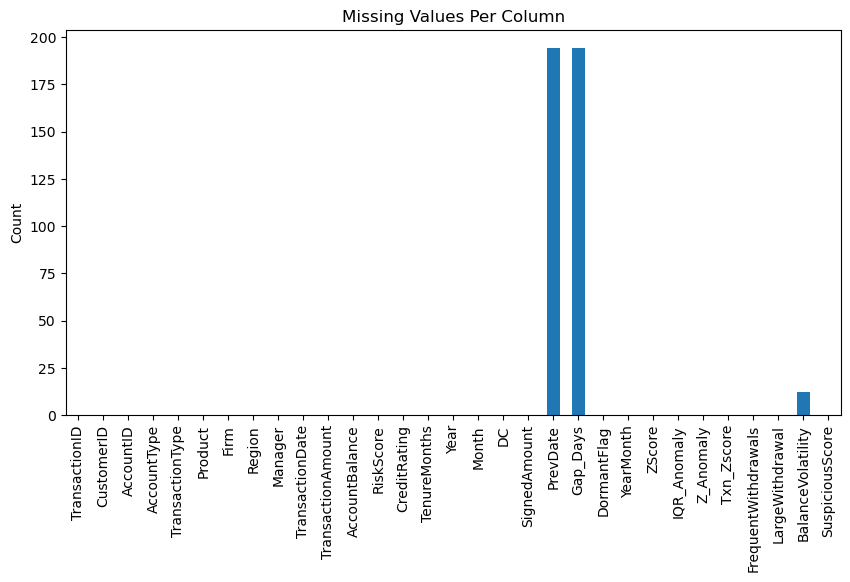

In [107]:
plt.figure(figsize=(10,5))
GS.isna().sum().plot(kind='bar')
plt.title("Missing Values Per Column")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

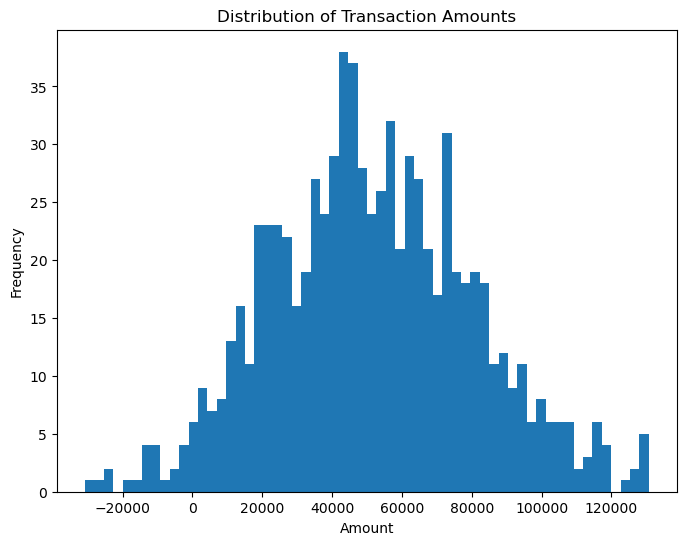

In [108]:
plt.figure(figsize=(8,6))
plt.hist(GS["TransactionAmount"], bins=60)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

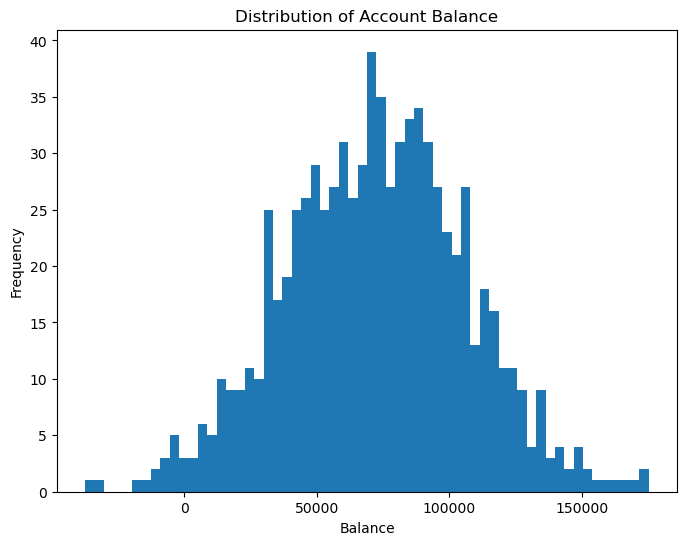

In [109]:
plt.figure(figsize=(8,6))
plt.hist(GS["AccountBalance"], bins=60)
plt.title("Distribution of Account Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

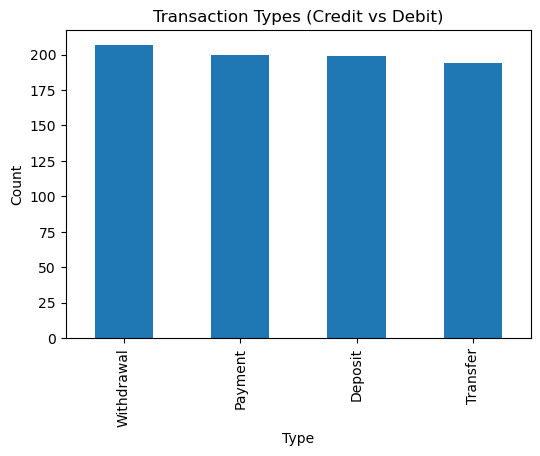

In [110]:
plt.figure(figsize=(6,4))
GS["TransactionType"].value_counts().plot(kind='bar')
plt.title("Transaction Types (Credit vs Debit)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

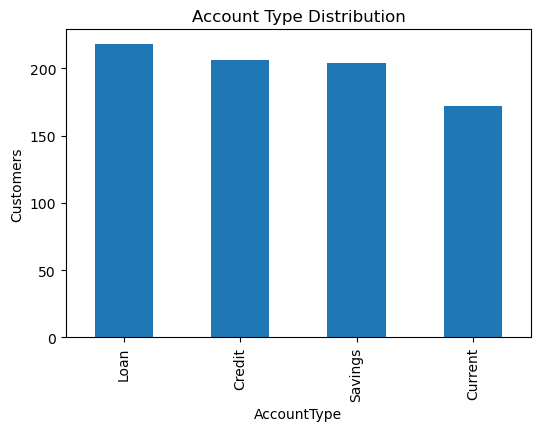

In [111]:
plt.figure(figsize=(6,4))
GS["AccountType"].value_counts().plot(kind="bar")
plt.title("Account Type Distribution")
plt.ylabel("Customers")
plt.show()

TypeError: bar_label() missing 1 required positional argument: 'container'

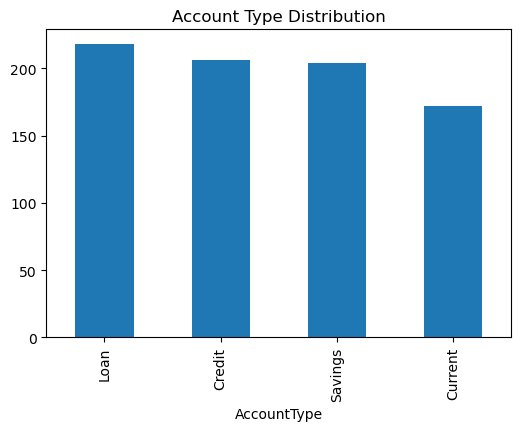

In [156]:
plt.figure(figsize=(6,4))
GS["AccountType"].value_counts().plot(kind="bar")
plt.title("Account Type Distribution")
plt.bar_label()
plt.ylabel("Customers")
plt.show()

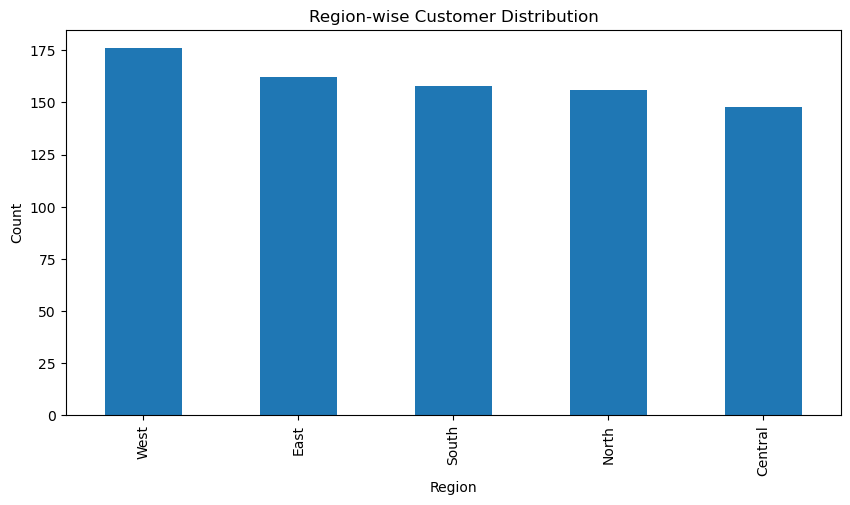

In [112]:
plt.figure(figsize=(10,5))
GS["Region"].value_counts().plot(kind="bar")
plt.title("Region-wise Customer Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()

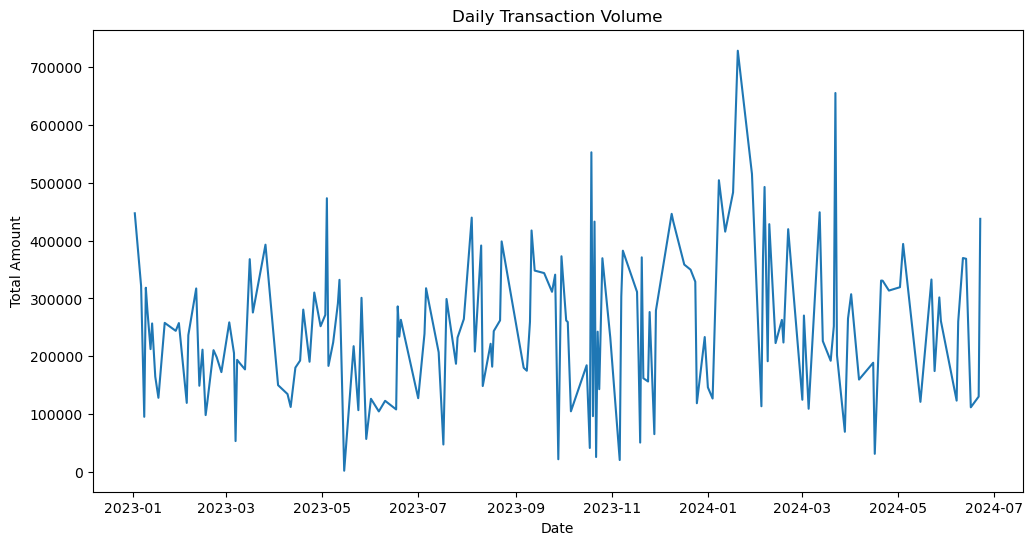

In [113]:
GS["TransactionDate"] = pd.to_datetime(GS["TransactionDate"])
daily = GS.groupby("TransactionDate")["TransactionAmount"].sum()

plt.figure(figsize=(12,6))
plt.plot(daily)
plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.show()

In [114]:
plt.figure(figsize=(10,8))
plt.imshow(GS.corr(), cmap="coolwarm")
plt.xticks(range(len(GS.corr())), GS.corr().columns, rotation=90)
plt.yticks(range(len(GS.corr())), GS.corr().columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'CUST9209'

<Figure size 1000x800 with 0 Axes>

## ValueError: could not convert string to float: 'CUST9209'

In [115]:
GS.corr()

ValueError: could not convert string to float: 'CUST9209'

In [116]:
ValueError: could not convert string to float: 'CUST9209'

SyntaxError: invalid syntax (2308873828.py, line 1)

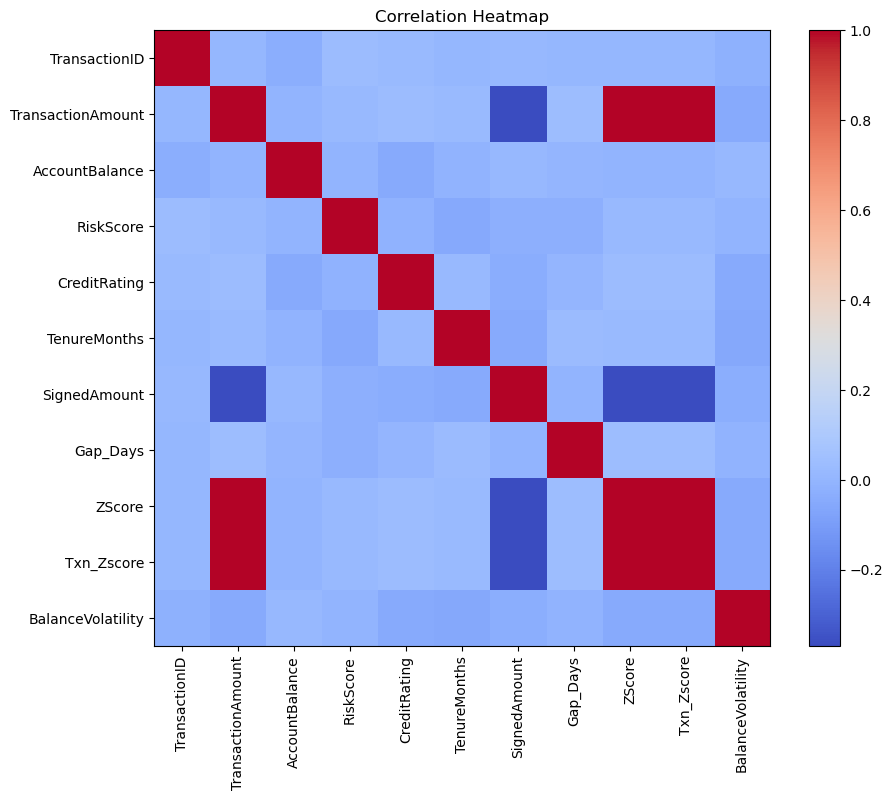

In [117]:
numeric_GS = GS.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
plt.imshow(numeric_GS.corr(), cmap="coolwarm")
plt.xticks(range(len(numeric_GS.corr())), numeric_GS.corr().columns, rotation=90)
plt.yticks(range(len(numeric_GS.corr())), numeric_GS.corr().columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()


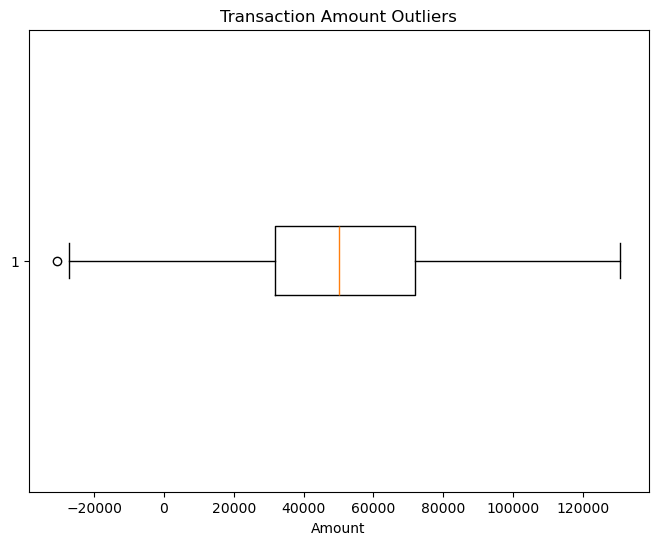

In [118]:
plt.figure(figsize=(8,6))
plt.boxplot(GS["TransactionAmount"], vert=False)
plt.title("Transaction Amount Outliers")
plt.xlabel("Amount")
plt.show()

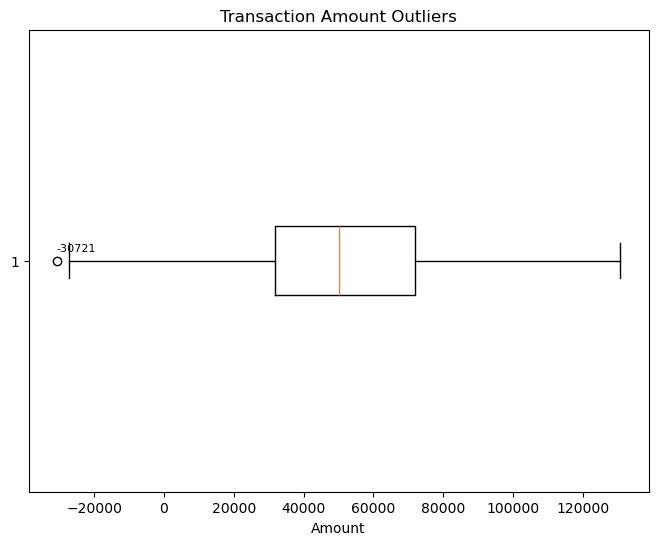

In [119]:
plt.figure(figsize=(8,6))

# draw boxplot and extract statistics + outliers
box = plt.boxplot(GS["TransactionAmount"], vert=False, showfliers=True)

plt.title("Transaction Amount Outliers")
plt.xlabel("Amount")

# Extract outlier (fliers) points
outliers = box['fliers'][0].get_xdata()

# Add labels to each outlier
for val in outliers:
    plt.text(
        val,                  # x-position
        1.02,                 # y-position (slightly above the plot line)
        str(int(val)),        # label text
        fontsize=8
    )

plt.show()


In [120]:
GS["BalanceSegment"] = pd.qcut(GS["AccountBalance"],
                               q=3,
                               labels=["Low Balance", "Medium Balance", "High Balance"])

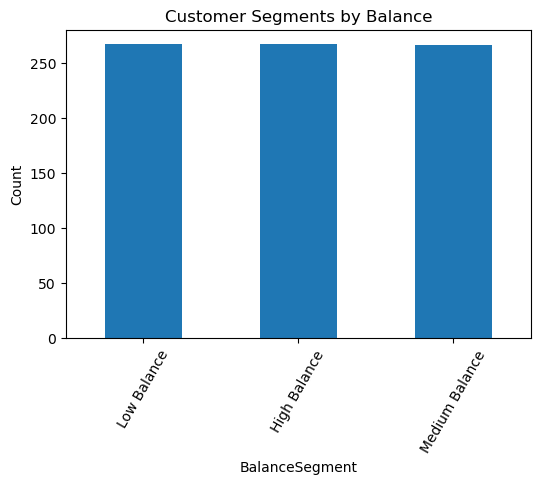

In [121]:
plt.figure(figsize=(6,4))
GS["BalanceSegment"].value_counts().plot(kind="bar")
plt.title("Customer Segments by Balance")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.show()

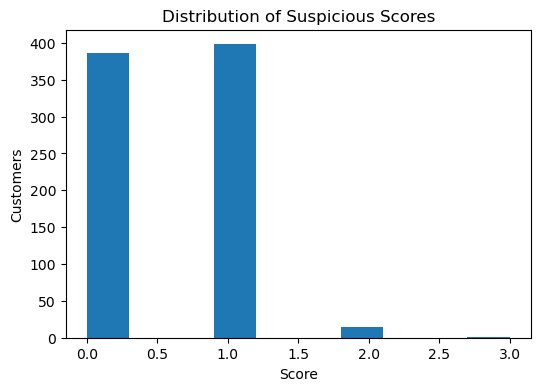

In [122]:
plt.figure(figsize=(6,4))
plt.hist(GS["SuspiciousScore"], bins=10)
plt.title("Distribution of Suspicious Scores")
plt.xlabel("Score")
plt.ylabel("Customers")
plt.show()

In [123]:
GS.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'DC', 'SignedAmount',
       'PrevDate', 'Gap_Days', 'DormantFlag', 'YearMonth', 'ZScore',
       'IQR_Anomaly', 'Z_Anomaly', 'Txn_Zscore', 'FrequentWithdrawals',
       'LargeWithdrawal', 'BalanceVolatility', 'SuspiciousScore',
       'BalanceSegment'],
      dtype='object')

# Task 6

### Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.


In [124]:
txn_counts = GS.groupby("CustomerID")["TransactionID"].count()
threshold = txn_counts.median()
GS["VolumeGroup"] = GS["CustomerID"].map(
    lambda x: "High" if txn_counts[x] >= threshold else "Low"
)

In [125]:
total_amount = GS.groupby("CustomerID")["TransactionAmount"].sum()
threshold = total_amount.median()
GS["VolumeGroup"] = GS["CustomerID"].map(
    lambda x: "High" if total_amount[x] >= threshold else "Low"
)

In [126]:
high_balances = GS[GS["VolumeGroup"] == "High"]["AccountBalance"]
low_balances  = GS[GS["VolumeGroup"] == "Low"]["AccountBalance"]

In [127]:
high_balances.head()

468     65506.30662
25     133706.90550
87     113773.11710
384     74266.92352
294     84694.55080
Name: AccountBalance, dtype: float64

In [128]:
low_balances.head()

742     22737.83269
469     65478.53271
611     47038.78881
195     95766.76022
21     137018.54730
Name: AccountBalance, dtype: float64

In [129]:
from scipy.stats import ttest_ind

In [130]:
t_stat, p_value = ttest_ind(high_balances, low_balances, equal_var=False)
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 1.6432821187746736
P-Value: 0.10088629398231536


<Figure size 600x400 with 0 Axes>

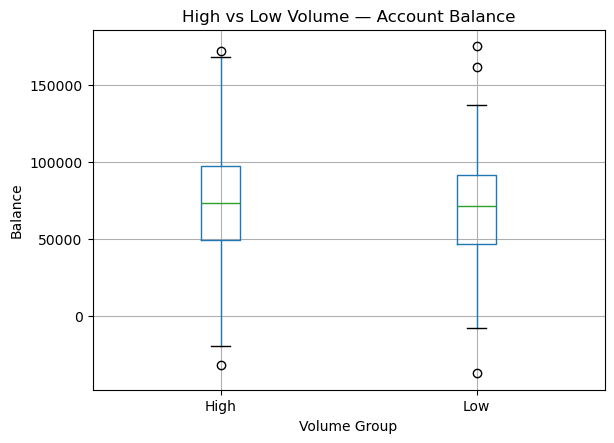

In [131]:
plt.figure(figsize=(6,4))
GS.boxplot(column="AccountBalance", by="VolumeGroup")
plt.title("High vs Low Volume — Account Balance")
plt.suptitle("")   # remove extra title
plt.xlabel("Volume Group")
plt.ylabel("Balance")
plt.show()

In [132]:
GS[["CustomerID", "VolumeGroup"]].head()

,CustomerID,VolumeGroup
468,CUST9209,High
25,CUST3109,High
87,CUST8155,High
742,CUST3810,Low
384,CUST3041,High


In [133]:
GS["VolumeGroup"].value_counts()

VolumeGroup
High    529
Low     271
Name: count, dtype: int64

In [134]:
GS.groupby("VolumeGroup")["AccountBalance"].mean()

VolumeGroup
High    73746.825989
Low     69610.536456
Name: AccountBalance, dtype: float64

### ● Conduct hypothesis testing based on segmentation.

In [135]:
segment_col = "BalanceSegment"

In [136]:
metric_col = "AccountBalance"

In [137]:
group1 = GS[GS[segment_col] == GS[segment_col].unique()[0]][metric_col]
group2 = GS[GS[segment_col] == GS[segment_col].unique()[1]][metric_col]

In [138]:
group1 = GS[GS["BalanceSegment"] == "High"]["AccountBalance"]
group2 = GS[GS["BalanceSegment"] == "Low"]["AccountBalance"]

In [139]:
from scipy.stats import ttest_ind

In [140]:
t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: nan
P-value: nan


In [141]:
group_high = GS[GS["BalanceSegment"] == "High"]["TransactionAmount"]
group_low  = GS[GS["BalanceSegment"] == "Low"]["TransactionAmount"]
t_stat, p_value = ttest_ind(group_high, group_low, equal_var=False)
print(t_stat, p_value)

nan nan


In [142]:
median_risk = GS["RiskScore"].median()
GS["RiskGroup"] = GS["RiskScore"].apply(lambda x: "High" if x >= median_risk else "Low")
high_risk_txn = GS[GS["RiskGroup"] == "High"]["TransactionAmount"]
low_risk_txn  = GS[GS["RiskGroup"] == "Low"]["TransactionAmount"]
t_stat, p_value = ttest_ind(high_risk_txn, low_risk_txn, equal_var=False)
print(t_stat, p_value)

0.2952760575331599 0.7678598127325659


In [143]:
result = pd.DataFrame({
    "Group 1 Mean": [group1.mean()],
    "Group 2 Mean": [group2.mean()],
    "T-Statistic": [t_stat],
    "P-Value": [p_value]
})
result

,Group 1 Mean,Group 2 Mean,T-Statistic,P-Value
0,NaN,NaN,0.295276,0.76786


In [144]:
GS.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,...,IQR_Anomaly,Z_Anomaly,Txn_Zscore,FrequentWithdrawals,LargeWithdrawal,BalanceVolatility,SuspiciousScore,BalanceSegment,VolumeGroup,RiskGroup
468,73,CUST9209,ACC10117,Savings,Transfer,Credit Card,Firm E,West,Manager 1,2023-01-30,...,0,0,-0.153026,False,0,15042.859667,0,Medium Balance,High,Low
25,34,CUST3109,ACC10117,Savings,Deposit,Home Loan,Firm E,West,Manager 3,2023-02-21,...,0,0,0.582509,False,0,30728.547118,0,High Balance,High,Low
87,106,CUST8155,ACC10117,Credit,Deposit,Mutual Fund,Firm C,East,Manager 3,2023-06-18,...,0,0,-0.200682,False,0,44945.765057,1,High Balance,High,High
742,169,CUST3810,ACC10117,Loan,Deposit,Home Loan,Firm B,East,Manager 4,2024-03-14,...,0,1,-2.273881,False,0,25640.152184,1,Low Balance,Low,Low
384,158,CUST3041,ACC10996,Savings,Withdrawal,Credit Card,Firm B,South,Manager 3,2023-05-08,...,0,0,-0.554582,False,0,29351.363244,0,Medium Balance,High,High


In [145]:
GS.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths', 'Year', 'Month', 'DC', 'SignedAmount',
       'PrevDate', 'Gap_Days', 'DormantFlag', 'YearMonth', 'ZScore',
       'IQR_Anomaly', 'Z_Anomaly', 'Txn_Zscore', 'FrequentWithdrawals',
       'LargeWithdrawal', 'BalanceVolatility', 'SuspiciousScore',
       'BalanceSegment', 'VolumeGroup', 'RiskGroup'],
      dtype='object')

In [146]:
GS.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 468 to 510
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   TransactionID        800 non-null    int64         
 1   CustomerID           800 non-null    object        
 2   AccountID            800 non-null    object        
 3   AccountType          800 non-null    object        
 4   TransactionType      800 non-null    object        
 5   Product              800 non-null    object        
 6   Firm                 800 non-null    object        
 7   Region               800 non-null    object        
 8   Manager              800 non-null    object        
 9   TransactionDate      800 non-null    datetime64[ns]
 10  TransactionAmount    800 non-null    float64       
 11  AccountBalance       800 non-null    float64       
 12  RiskScore            800 non-null    float64       
 13  CreditRating         800 non-null    i

In [147]:
GS.shape

(800, 34)

In [148]:
len(GS)

800